In [1]:
import dr_datacube
import numpy as np
import polars as pl

from matplotlib import pyplot as plt

In [2]:
df = pl.read_parquet("/Users/corbettb/Documents/GitHub/dynamic_routing_facemap/results/facemap_lick_decoding.parquet")

Text(0, 0.5, 'CV Score: lick vs no lick trials')

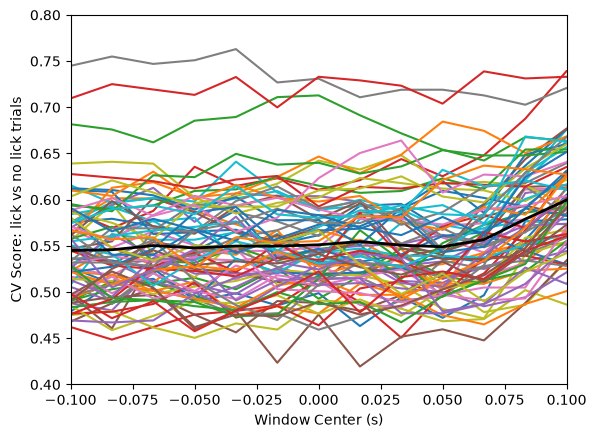

In [18]:
window_centers  = np.array(df['window_end_s'][0])

scores = np.stack(df['cv_scores'].to_numpy())

plt.plot(window_centers, scores.T)
plt.plot(window_centers, scores.mean(axis=0), color='k', linewidth=2)

plt.xlim(-0.1, 0.1)
plt.ylim(0.4, 0.8)
plt.xlabel('Window Center (s)')
plt.ylabel('CV Score: lick vs no lick trials')

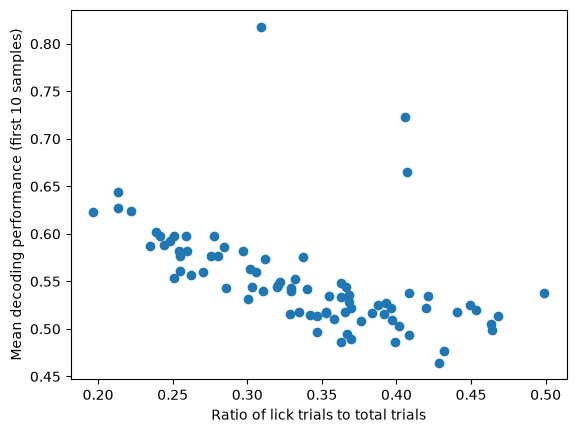

In [24]:
# plot the ratio of lick trials to total trials against the decoding performance in first 10 samples
ratio = df["n_lick_trials"] / df["n_trials"]
performance_first_10 = df.with_columns(
    pl.col("cv_scores").list.slice(0, 10).alias("performance_first_10")
).select("performance_first_10")

mean_performance_first_10 = performance_first_10.select(
    pl.col("performance_first_10").list.mean()
).to_series()

plt.scatter(ratio, mean_performance_first_10)
plt.xlabel("Ratio of lick trials to total trials")
plt.ylabel("Mean decoding performance (first 10 samples)")
plt.show()